Axes(0.185719,0.11;0.653562x0.77)


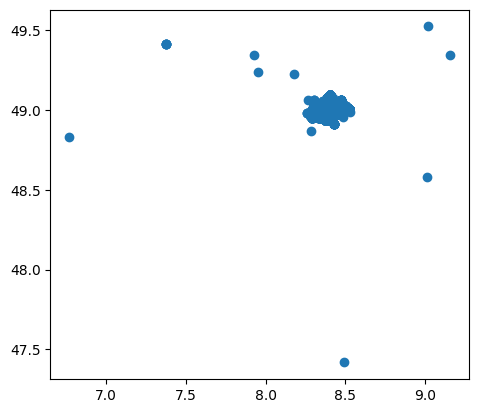

In [1]:
import pandas as pd
import geopandas as gpd
from shapely import Point


# pandas: read csv
path = r'S:\Studium\3. Semester\VSMB 330 Digitalisierung und Mobilsoftware\Projektarbeit\NextBikeData as CSV\bike_locations.csv'
df = pd.read_csv(path)
#print(df.columns)

# shapely: create geometry
geometry_col = [Point(xy) for xy in zip(df['lng'], df['lat'])]
#print(geometry_col[:4])

# geopandas: host geospatial layer
spatial_data = gpd.GeoDataFrame(df, geometry= geometry_col)
spatial_data.set_crs(4326)
print(spatial_data.plot())

In [11]:
import ipywidgets as widgets
from IPython.display import display

date_picker = widgets.DatePicker(
    description='Tag:',
    disabled=False
)

def update_map(change):
    if change["new"] is not None:
        date_str = change["new"].strftime("%Y-%m-%d")
        display(map_for_date(date_str))

date_picker.observe(update_map, names='value')
display(date_picker)


DatePicker(value=None, description='Tag:', step=1)

In [6]:
import sqlite3
import pandas as pd
import folium
import ipywidgets as widgets
from IPython.display import display, clear_output
from datetime import datetime

def create_bike_map(bike_number):
    # connect to database
    conn = sqlite3.connect("nextbike_data_old.db")
    query = """
        SELECT *
        FROM bike_locations
        WHERE bike_number = ?
        ORDER BY timestamp
    """

    df = pd.read_sql_query(query, conn, params=(bike_number,))
    conn.close()

    if df.empty:
        print("Keine Daten für diesen Tag")
        return None
    
    # mean of the position of all bikes
    center_lat = df['lat'].mean()
    center_lng = df['lng'].mean()

    m = folium.Map(
        location=[center_lat, center_lng],
        zoom_start=13,
        tiles='OpenStreetMap'
    )

    m._children.clear()

    # all positions of the bike as a timeline
    for _, row in df.iterrows(): # type: ignore
        folium.CircleMarker(
            location=[row['lat'], row['lng']],
            radius=6,
            popup=f"{row['name']} (Bike {row['bike_number']})<br>{row['timestamp']}",
            color="red",
            fill=True,
            fill_opacity=0.8,
            tooltip=f"{row['timestamp'][:16]}"
        ).add_to(m)

    # line for tracing the bikes path
    folium.PolyLine(
        locations=df[['lat', 'lng']].values.tolist(),
        color="blue",
        weight=3,
        opacity=0.7,
        popup="Bewegungsverlauf dieses Bikes"
    ).add_to(m)
    
    return m

# Load all bikes
conn = sqlite3.connect("nextbike_data_old.db")
bikes_df = pd.read_sql_query("SELECT DISTINCT bike_number FROM bike_locations ORDER BY bike_number", conn)
conn.close()

bike_dropdown = widgets.Dropdown(
    options=bikes_df["bike_number"].tolist(),
    value=bikes_df["bike_number"].iloc[0],
    description='Bitte wählen:',
    style={'description_width': 'initial'}
)

output = widgets.Output()

def update_map(change):
    with output:
        clear_output(wait=True)
        bike_num = change['new']
        print(f"Lade Karte für Bike {bike_num}...")
        m = create_bike_map(bike_num)
        if m:
            display(m)

bike_dropdown.observe(update_map, names='value')

#ui: dropdown + output
ui = widgets.VBox([
    bike_dropdown,
    output
])

update_map({'new': bike_dropdown.value})
display(ui)

In [8]:
update_map({'new': bike_dropdown.value})